# PRCP-1023 - Johns Hopkins COVID-19 Prediction Analysis

**Project:** Johns Hopkins COVID-19 Case and Death Prediction  
**Domain:** Healthcare  
**Candidate:** Ravi Kumar/Jackson/Bindhu  

## Problem Statement

The purpose of this project is to study the COVID-19 data published by Johns Hopkins University and prepare a complete analysis report.  
Along with the analysis, the project also builds predictive models to forecast future confirmed cases and deaths for a selected country.

For this project, I have selected **India** as the country for analysis and prediction.

## Project Objectives

1. Prepare a complete data analysis report on the given COVID-19 dataset.
2. Forecast confirmed cases and deaths for a fixed future period.
3. Compare multiple machine learning models and recommend the best model.
4. Provide suggestions to the government health department based on the forecast.
5. Document the challenges faced and the techniques used to handle them.

## 1. Import Required Libraries

In this section, we import all the libraries required for data handling, visualization, model building, and model evaluation.

### Simple Explanation

- `pandas` helps us work with tables and CSV files.
- `numpy` helps with numerical calculations.
- `matplotlib` and `seaborn` help us create charts.
- `sklearn` helps us build and compare machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The project uses two Johns Hopkins COVID-19 files:

1. `time_series_covid19_confirmed_global.csv`
2. `time_series_covid19_deaths_global.csv`

These files contain country-wise cumulative COVID-19 confirmed cases and death cases across multiple dates.

### Simple Explanation

The dataset is in time-series format. Each date column represents the total confirmed cases or deaths recorded till that date.

In [2]:
# Please keep both CSV files in this folder
project_path = r"E:\Capstone Project\Covid Prediction (Johns Hopkins) (PRCP-1023)"

confirmed_file = os.path.join(project_path, "time_series_covid19_confirmed_global.csv")
deaths_file = os.path.join(project_path, "time_series_covid19_deaths_global.csv")

# If the notebook is placed in the same folder as the CSV files, this backup will also work
if not os.path.exists(confirmed_file):
    confirmed_file = "time_series_covid19_confirmed_global.csv"

if not os.path.exists(deaths_file):
    deaths_file = "time_series_covid19_deaths_global.csv"

confirmed_df = pd.read_csv(confirmed_file)
deaths_df = pd.read_csv(deaths_file)

print("Confirmed Data Shape:", confirmed_df.shape)
print("Deaths Data Shape:", deaths_df.shape)

display(confirmed_df.head())

Confirmed Data Shape: (289, 1147)
Deaths Data Shape: (289, 1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,...,2/23/23,2/24/23,2/25/23,2/26/23,2/27/23,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,...,209215,209230,209246,209274,209308,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,...,334345,334356,334373,334378,334380,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,0,0,0,0,0,...,271432,271436,271439,271440,271440,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,0,0,0,0,0,...,47866,47866,47866,47866,47866,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,0,0,0,0,0,...,105205,105205,105205,105205,105255,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


## 3. Dataset Overview

Here, we look at the first few records and understand the structure of both datasets.

### Simple Explanation

The first four columns contain location details such as country, province/state, latitude, and longitude.  
From the fifth column onwards, each column represents a date.

In [3]:
print("Confirmed Dataset Preview:")
display(confirmed_df.head())

print()
print("Deaths Dataset Preview:")
display(deaths_df.head())

print()
print("Confirmed Dataset Info:")
confirmed_df.info()

print()
print("Deaths Dataset Info:")
deaths_df.info()

Confirmed Dataset Preview:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,...,2/23/23,2/24/23,2/25/23,2/26/23,2/27/23,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,...,209215,209230,209246,209274,209308,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,...,334345,334356,334373,334378,334380,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,0,0,0,0,0,...,271432,271436,271439,271440,271440,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,0,0,0,0,0,...,47866,47866,47866,47866,47866,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,0,0,0,0,0,...,105205,105205,105205,105205,105255,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



Deaths Dataset Preview:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,...,2/23/23,2/24/23,2/25/23,2/26/23,2/27/23,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,0,0,0,0,0,...,1931,1931,1931,1931,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933



Confirmed Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB

Deaths Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


## 4. Missing Value Check

Before doing any analysis, we check whether the dataset contains missing values.

### Simple Explanation

Missing values can create problems during analysis and model building.  
Here, most missing values are expected in the `Province/State` column because many countries do not have province-level records.

In [4]:
print("Missing values in Confirmed Dataset:")
print(confirmed_df.isnull().sum().sort_values(ascending=False).head(10))

print()
print("Missing values in Deaths Dataset:")
print(deaths_df.isnull().sum().sort_values(ascending=False).head(10))

Missing values in Confirmed Dataset:
Province/State    198
Long                2
Lat                 2
2/21/23             0
1/29/20             0
3/9/23              0
Country/Region      0
1/22/20             0
1/23/20             0
1/24/20             0
dtype: int64

Missing values in Deaths Dataset:
Province/State    198
Long                2
Lat                 2
2/21/23             0
1/29/20             0
3/9/23              0
Country/Region      0
1/22/20             0
1/23/20             0
1/24/20             0
dtype: int64


## 5. Country Selection

For this analysis, I selected **India**.

### Why India?

India is a good choice for this project because it has a large COVID-19 history and the trend includes different pandemic phases.  
This makes it useful for both analysis and forecasting.

In [5]:
selected_country = "India"

country_confirmed = confirmed_df[confirmed_df["Country/Region"] == selected_country]
country_deaths = deaths_df[deaths_df["Country/Region"] == selected_country]

print("Selected Country:", selected_country)
print("Confirmed rows selected:", country_confirmed.shape)
print("Death rows selected:", country_deaths.shape)

display(country_confirmed.head())

Selected Country: India
Confirmed rows selected: (1, 1147)
Death rows selected: (1, 1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,2/1/20,...,2/23/23,2/24/23,2/25/23,2/26/23,2/27/23,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
148,NaN,India,20.593684,78.96288,0,0,0,0,0,0,0,0,1,1,1,...,44686842,44687025,44687243,44687428,44687597,44687837,44688105,44688388,44688722,44689046,44689327,44689593,44689919,44690298,44690738


## 6. Data Transformation

The original dataset has dates as columns. For analysis and prediction, we need dates as rows.

### Simple Explanation

Currently, the dataset is in a wide format.  
We convert it into a clean time-series format where each row represents one date.

The final dataset will have:

- Date
- Confirmed Cases
- Death Cases
- Daily Confirmed Cases
- Daily Death Cases
- Mortality Rate

In [6]:
# Date columns start from the 5th column onwards
date_columns = confirmed_df.columns[4:]

# Summing is used because some countries may have multiple province/state rows
confirmed_series = country_confirmed[date_columns].sum().reset_index()
deaths_series = country_deaths[date_columns].sum().reset_index()

confirmed_series.columns = ["Date", "Confirmed_Cases"]
deaths_series.columns = ["Date", "Death_Cases"]

# Merge confirmed and deaths data into one table
covid_country = pd.merge(confirmed_series, deaths_series, on="Date")

# Convert Date from text to actual date format
covid_country["Date"] = pd.to_datetime(covid_country["Date"])

# Calculate daily cases from cumulative cases
covid_country["Daily_Confirmed_Cases"] = covid_country["Confirmed_Cases"].diff().fillna(0)
covid_country["Daily_Death_Cases"] = covid_country["Death_Cases"].diff().fillna(0)

# Sometimes reporting corrections may create negative daily values. We convert them to 0.
covid_country["Daily_Confirmed_Cases"] = covid_country["Daily_Confirmed_Cases"].clip(lower=0)
covid_country["Daily_Death_Cases"] = covid_country["Daily_Death_Cases"].clip(lower=0)

# Calculate mortality rate
covid_country["Mortality_Rate"] = (covid_country["Death_Cases"] / covid_country["Confirmed_Cases"]) * 100
covid_country["Mortality_Rate"] = covid_country["Mortality_Rate"].replace([np.inf, -np.inf], np.nan).fillna(0)

display(covid_country.head())

,Date,Confirmed_Cases,Death_Cases,Daily_Confirmed_Cases,Daily_Death_Cases,Mortality_Rate
0,2020-01-22,0,0,0.0,0.0,0.0
1,2020-01-23,0,0,0.0,0.0,0.0
2,2020-01-24,0,0,0.0,0.0,0.0
3,2020-01-25,0,0,0.0,0.0,0.0
4,2020-01-26,0,0,0.0,0.0,0.0


## 7. Prepared Dataset Overview

Now we check the cleaned dataset after transformation.

### Simple Explanation

This prepared dataset will be used for visualization, model building, and forecasting.

In [7]:
print("Prepared Dataset Shape:", covid_country.shape)

print()
print("Dataset Information:")
covid_country.info()

print()
print("Summary Statistics:")
display(covid_country.describe())

print()
print("Last 5 records:")
display(covid_country.tail())

Prepared Dataset Shape: (1143, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1143 non-null   datetime64[ns]
 1   Confirmed_Cases        1143 non-null   int64         
 2   Death_Cases            1143 non-null   int64         
 3   Daily_Confirmed_Cases  1143 non-null   float64       
 4   Daily_Death_Cases      1143 non-null   float64       
 5   Mortality_Rate         1143 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 53.7 KB

Summary Statistics:


,Date,Confirmed_Cases,Death_Cases,Daily_Confirmed_Cases,Daily_Death_Cases,Mortality_Rate
count,1143,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,2021-08-15 00:00:00,2.548654e+07,319266.174103,39102.275591,464.374453,1.446624
min,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,2020-11-02 12:00:00,8.290750e+06,123354.000000,2063.500000,20.000000,1.188316
50%,2021-08-15 00:00:00,3.222551e+07,431642.000000,13615.000000,179.000000,1.326823
75%,2022-05-27 12:00:00,4.315163e+07,524579.000000,41898.000000,512.500000,1.449625
max,2023-03-09 00:00:00,4.469074e+07,530779.000000,414188.000000,7374.000000,3.595872
std,NaN,1.759640e+07,209966.402406,71630.868857,820.024092,0.626584



Last 5 records:


,Date,Confirmed_Cases,Death_Cases,Daily_Confirmed_Cases,Daily_Death_Cases,Mortality_Rate
1138,2023-03-05,44689327,530775,281.0,0.0,1.187700
1139,2023-03-06,44689593,530775,266.0,0.0,1.187693
1140,2023-03-07,44689919,530775,326.0,0.0,1.187684
1141,2023-03-08,44690298,530776,379.0,1.0,1.187676
1142,2023-03-09,44690738,530779,440.0,3.0,1.187671


## 8. Cumulative Confirmed Cases Trend

This chart shows the growth of total confirmed COVID-19 cases in India.

### Simple Explanation

Cumulative cases normally increase over time because each day’s cases are added to the previous total.

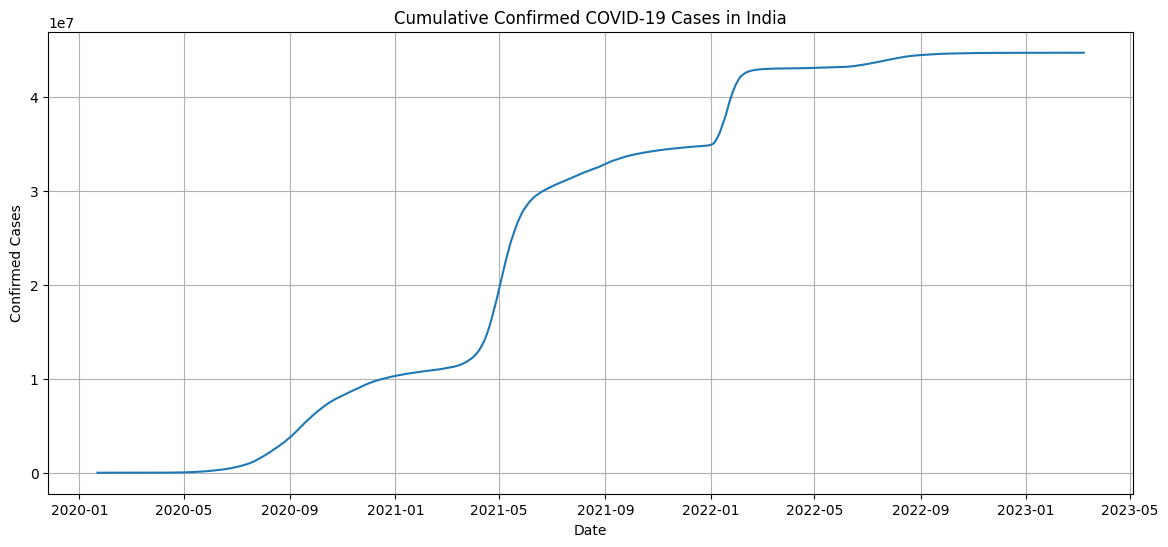

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(covid_country["Date"], covid_country["Confirmed_Cases"])
plt.title(f"Cumulative Confirmed COVID-19 Cases in {selected_country}")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()

## 9. Cumulative Death Cases Trend

This chart shows the total COVID-19 deaths over time.

### Simple Explanation

This helps us understand the long-term impact of COVID-19 on public health.

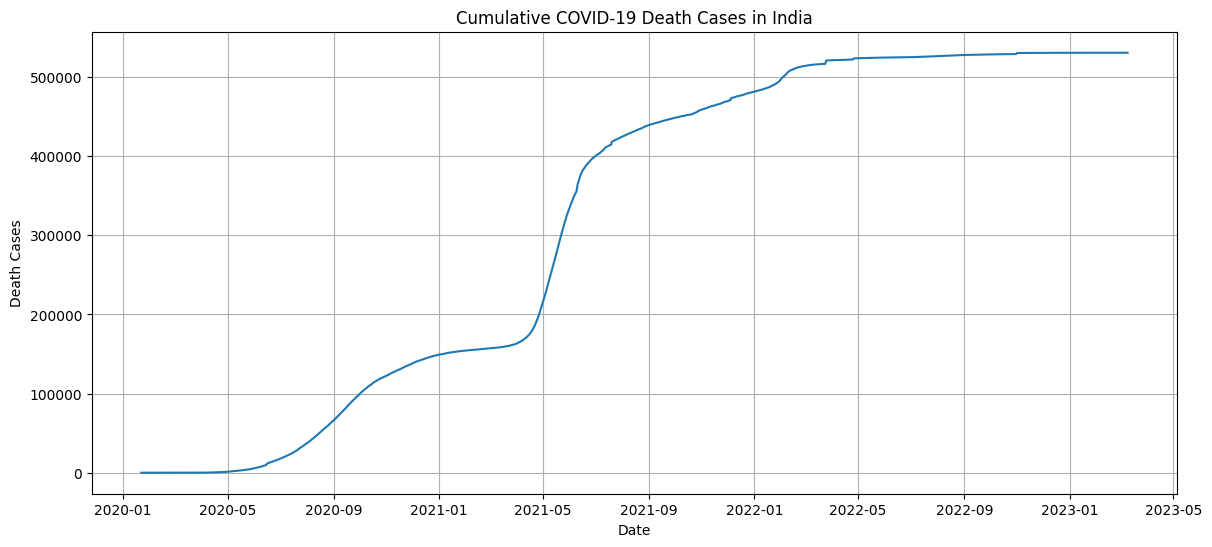

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(covid_country["Date"], covid_country["Death_Cases"])
plt.title(f"Cumulative COVID-19 Death Cases in {selected_country}")
plt.xlabel("Date")
plt.ylabel("Death Cases")
plt.grid(True)
plt.show()

## 10. Daily Confirmed Cases Trend

Daily confirmed cases help us identify waves and sudden increases.

### Simple Explanation

Daily cases are calculated by subtracting yesterday’s cumulative cases from today’s cumulative cases.

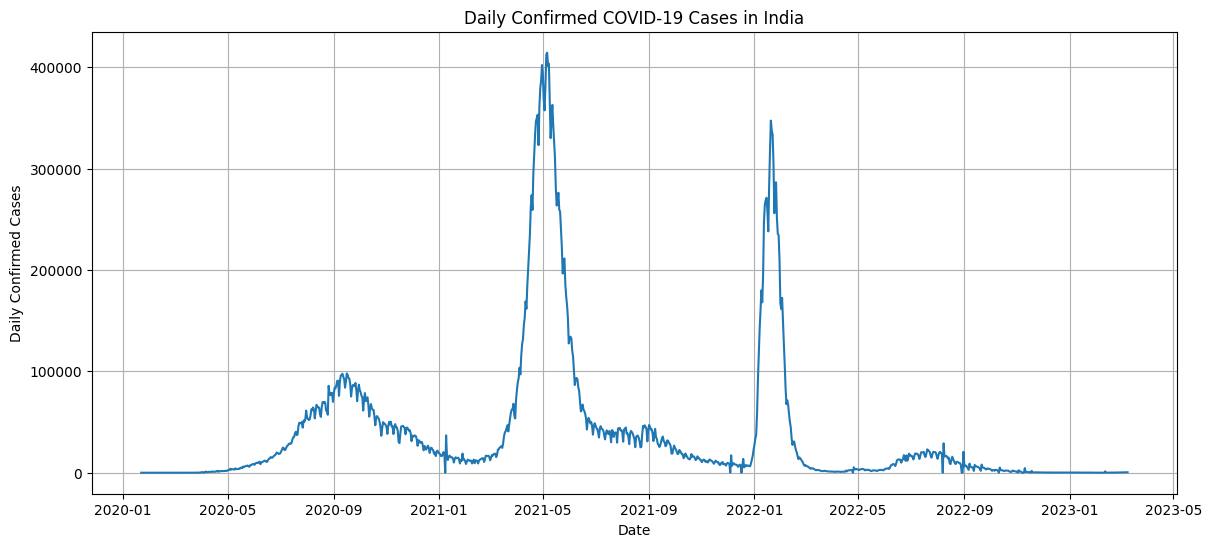

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(covid_country["Date"], covid_country["Daily_Confirmed_Cases"])
plt.title(f"Daily Confirmed COVID-19 Cases in {selected_country}")
plt.xlabel("Date")
plt.ylabel("Daily Confirmed Cases")
plt.grid(True)
plt.show()

## 11. Daily Death Cases Trend

This chart shows how many deaths were reported each day.

### Simple Explanation

A sudden rise in daily deaths may indicate pressure on hospitals and healthcare facilities.

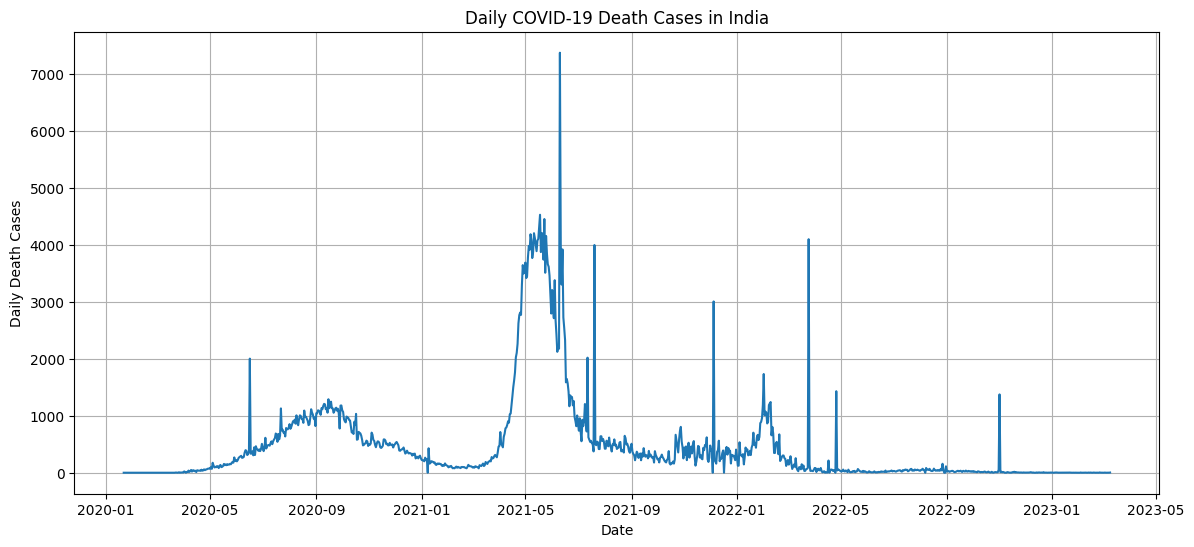

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(covid_country["Date"], covid_country["Daily_Death_Cases"])
plt.title(f"Daily COVID-19 Death Cases in {selected_country}")
plt.xlabel("Date")
plt.ylabel("Daily Death Cases")
plt.grid(True)
plt.show()

## 12. Mortality Rate Analysis

Mortality rate is calculated as:

`Death Cases / Confirmed Cases * 100`

### Simple Explanation

This tells us what percentage of confirmed cases resulted in deaths.

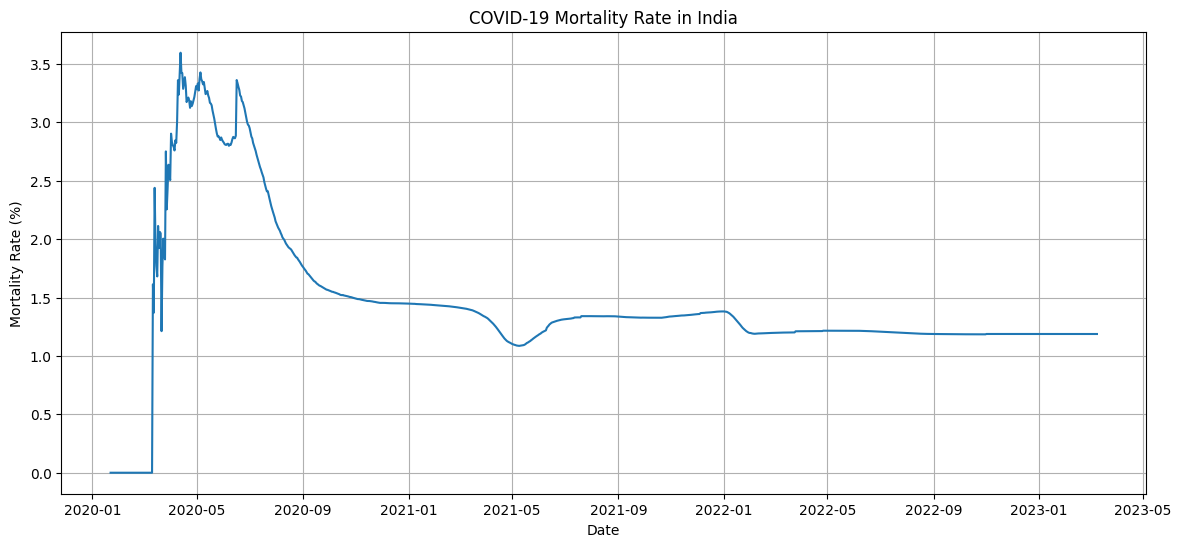

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(covid_country["Date"], covid_country["Mortality_Rate"])
plt.title(f"COVID-19 Mortality Rate in {selected_country}")
plt.xlabel("Date")
plt.ylabel("Mortality Rate (%)")
plt.grid(True)
plt.show()

## 13. Correlation Analysis

Correlation helps us understand the relationship between numerical variables.

### Simple Explanation

- A value close to 1 means a strong positive relationship.
- A value close to -1 means a strong negative relationship.
- A value close to 0 means a weak relationship.

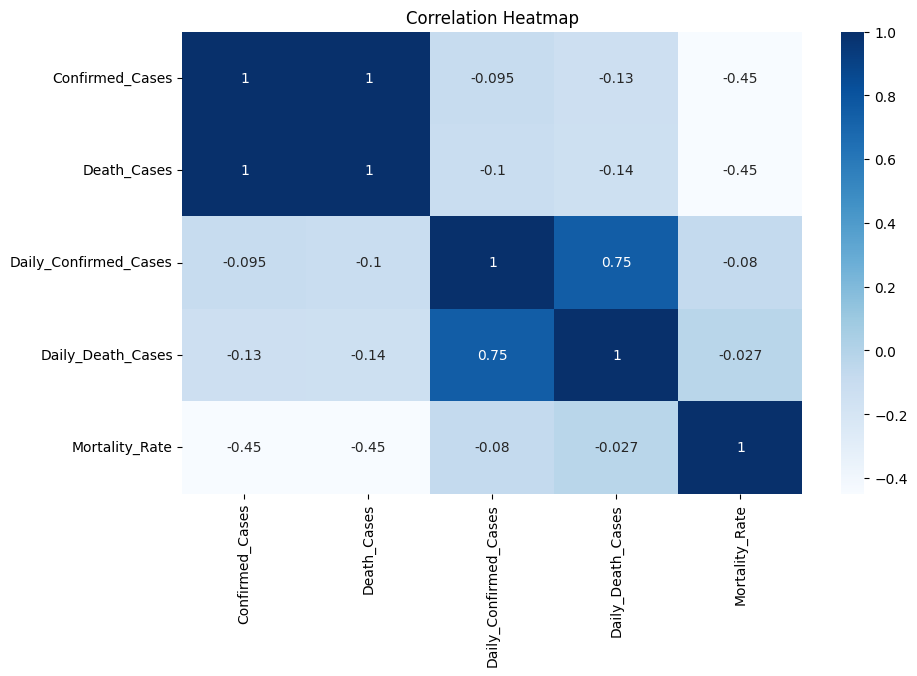

In [13]:
numeric_cols = [
    "Confirmed_Cases",
    "Death_Cases",
    "Daily_Confirmed_Cases",
    "Daily_Death_Cases",
    "Mortality_Rate"
]

plt.figure(figsize=(10, 6))
sns.heatmap(covid_country[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## 14. Feature Engineering

Machine learning models need numerical input features.  
So, we create useful features from the existing time-series data.

### Features Created

- `Days`: Number of days from the first date
- `Previous_Day_Cases`: Confirmed cases from the previous day
- `Previous_7_Day_Avg_Cases`: Average confirmed cases from the previous 7 days
- `Previous_Day_Deaths`: Death cases from the previous day
- `Previous_7_Day_Avg_Deaths`: Average death cases from the previous 7 days

### Simple Explanation

The model learns from recent past values to predict future values.

In [14]:
model_data = covid_country.copy()

# Convert dates into day numbers
model_data["Days"] = (model_data["Date"] - model_data["Date"].min()).dt.days

# Previous day and 7-day average features for confirmed cases
model_data["Previous_Day_Cases"] = model_data["Confirmed_Cases"].shift(1)
model_data["Previous_7_Day_Avg_Cases"] = model_data["Confirmed_Cases"].rolling(window=7).mean().shift(1)

# Previous day and 7-day average features for deaths
model_data["Previous_Day_Deaths"] = model_data["Death_Cases"].shift(1)
model_data["Previous_7_Day_Avg_Deaths"] = model_data["Death_Cases"].rolling(window=7).mean().shift(1)

# Remove rows with missing values created by shift and rolling average
model_data = model_data.dropna().reset_index(drop=True)

display(model_data.head())

,Date,Confirmed_Cases,Death_Cases,Daily_Confirmed_Cases,Daily_Death_Cases,Mortality_Rate,Days,Previous_Day_Cases,Previous_7_Day_Avg_Cases,Previous_Day_Deaths,Previous_7_Day_Avg_Deaths
0,2020-01-29,0,0,0.0,0.0,0.0,7,0.0,0.000000,0.0,0.0
1,2020-01-30,1,0,1.0,0.0,0.0,8,0.0,0.000000,0.0,0.0
2,2020-01-31,1,0,0.0,0.0,0.0,9,1.0,0.142857,0.0,0.0
3,2020-02-01,1,0,0.0,0.0,0.0,10,1.0,0.285714,0.0,0.0
4,2020-02-02,2,0,1.0,0.0,0.0,11,1.0,0.428571,0.0,0.0


## 15. Train-Test Split

Since this is time-series data, we do not use random splitting.

### Simple Explanation

For forecasting, old data should be used for training and recent data should be used for testing.  
This is closer to real-world prediction.

In [15]:
split_index = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_index]
test_data = model_data.iloc[split_index:]

features_cases = ["Days", "Previous_Day_Cases", "Previous_7_Day_Avg_Cases"]
target_cases = "Confirmed_Cases"

features_deaths = ["Days", "Previous_Day_Deaths", "Previous_7_Day_Avg_Deaths"]
target_deaths = "Death_Cases"

X_train_cases = train_data[features_cases]
y_train_cases = train_data[target_cases]
X_test_cases = test_data[features_cases]
y_test_cases = test_data[target_cases]

X_train_deaths = train_data[features_deaths]
y_train_deaths = train_data[target_deaths]
X_test_deaths = test_data[features_deaths]
y_test_deaths = test_data[target_deaths]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

Training Data Shape: (908, 11)
Testing Data Shape: (228, 11)


## 16. Model Comparison for Confirmed Cases

We compare three regression models:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

### Simple Explanation

We compare multiple models because one model may perform better than another.  
The best model is selected based on error values and R² score.

In [16]:
base_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

case_results = {}

for model_name, model in base_models.items():
    current_model = clone(model)
    current_model.fit(X_train_cases, y_train_cases)
    predictions = current_model.predict(X_test_cases)

    mae = mean_absolute_error(y_test_cases, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_cases, predictions))
    r2 = r2_score(y_test_cases, predictions)

    case_results[model_name] = {
        "Model Object": current_model,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

case_results_df = pd.DataFrame([
    {
        "Model": model_name,
        "MAE": values["MAE"],
        "RMSE": values["RMSE"],
        "R2 Score": values["R2 Score"]
    }
    for model_name, values in case_results.items()
]).sort_values(by="RMSE")

display(case_results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,12771.671115,13491.733092,0.994368
1,Random Forest Regressor,678083.216491,701508.872842,-14.227334
2,Gradient Boosting Regressor,696185.696731,719021.817834,-14.997115


## 17. Model Comparison for Death Cases

Now we perform the same model comparison for death cases.

### Simple Explanation

Confirmed cases and death cases may behave differently, so separate models are trained and compared.

In [17]:
death_results = {}

for model_name, model in base_models.items():
    current_model = clone(model)
    current_model.fit(X_train_deaths, y_train_deaths)
    predictions = current_model.predict(X_test_deaths)

    mae = mean_absolute_error(y_test_deaths, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_deaths, predictions))
    r2 = r2_score(y_test_deaths, predictions)

    death_results[model_name] = {
        "Model Object": current_model,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

death_results_df = pd.DataFrame([
    {
        "Model": model_name,
        "MAE": values["MAE"],
        "RMSE": values["RMSE"],
        "R2 Score": values["R2 Score"]
    }
    for model_name, values in death_results.items()
]).sort_values(by="RMSE")

display(death_results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,134.623646,162.124888,0.987714
1,Random Forest Regressor,3454.461579,3751.358334,-5.577915
2,Gradient Boosting Regressor,3680.580152,3960.562436,-6.332041


## 18. Best Model Selection

The best model is selected using the lowest RMSE value.

### Simple Explanation

RMSE is useful because it gives higher penalty to large prediction errors.  
For this project, lower RMSE means better forecasting performance.

In [18]:
best_case_model_name = case_results_df.iloc[0]["Model"]
best_death_model_name = death_results_df.iloc[0]["Model"]

best_case_model = case_results[best_case_model_name]["Model Object"]
best_death_model = death_results[best_death_model_name]["Model Object"]

print("Best Model for Confirmed Cases:", best_case_model_name)
print("Best Model for Death Cases:", best_death_model_name)

Best Model for Confirmed Cases: Linear Regression
Best Model for Death Cases: Linear Regression


## 19. Actual vs Predicted - Confirmed Cases

This chart compares actual confirmed cases with predicted confirmed cases.

### Simple Explanation

If the predicted line is close to the actual line, the model is performing well.

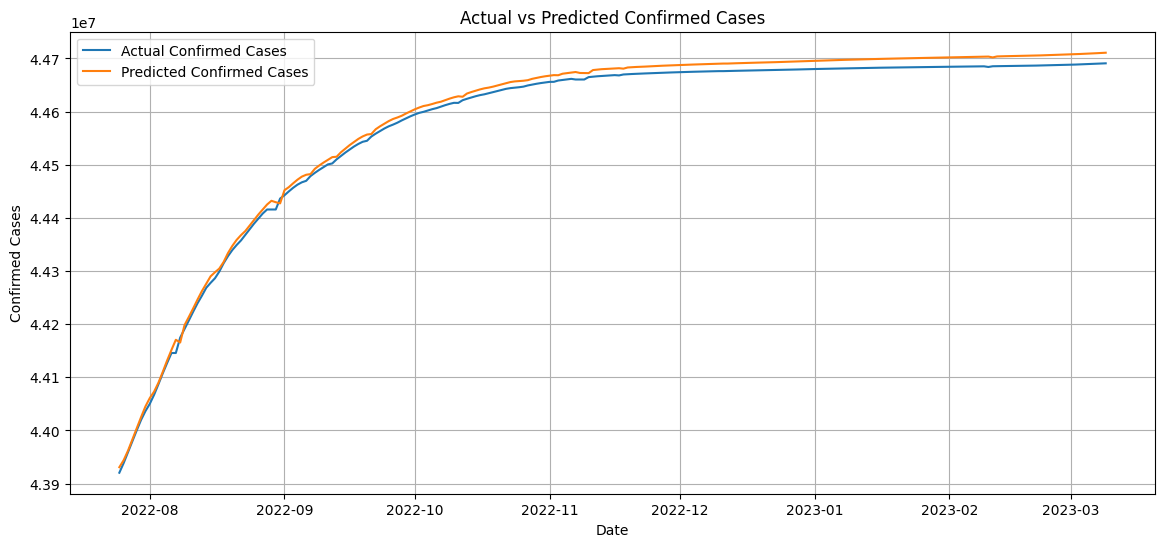

In [19]:
case_predictions = best_case_model.predict(X_test_cases)

plt.figure(figsize=(14, 6))
plt.plot(test_data["Date"], y_test_cases.values, label="Actual Confirmed Cases")
plt.plot(test_data["Date"], case_predictions, label="Predicted Confirmed Cases")
plt.title("Actual vs Predicted Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()

## 20. Actual vs Predicted - Death Cases

This chart compares actual death cases with predicted death cases.

### Simple Explanation

This helps us visually check how well the death prediction model is working.

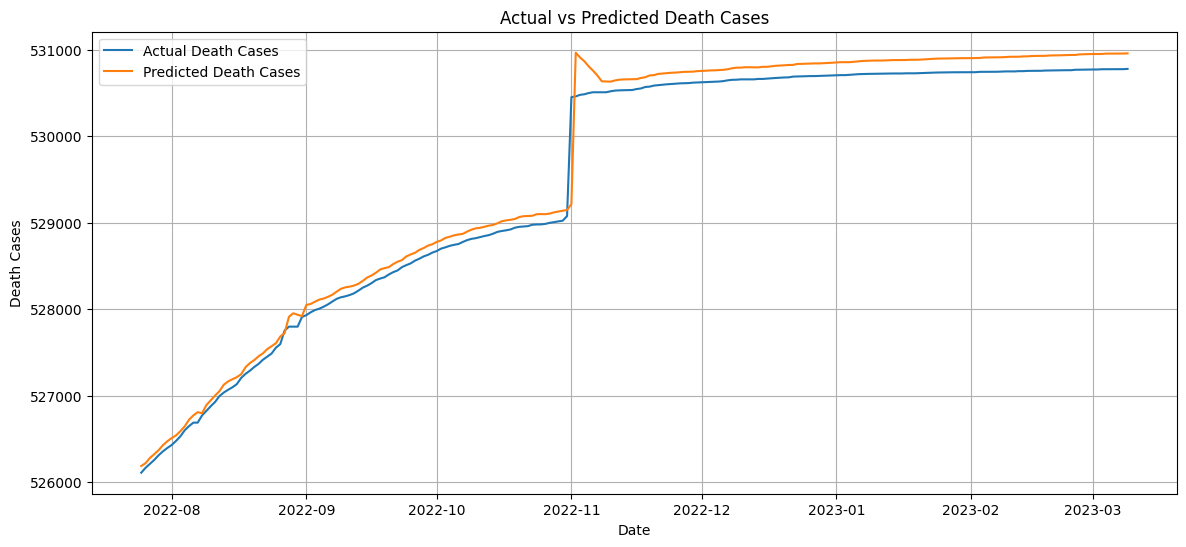

In [20]:
death_predictions = best_death_model.predict(X_test_deaths)

plt.figure(figsize=(14, 6))
plt.plot(test_data["Date"], y_test_deaths.values, label="Actual Death Cases")
plt.plot(test_data["Date"], death_predictions, label="Predicted Death Cases")
plt.title("Actual vs Predicted Death Cases")
plt.xlabel("Date")
plt.ylabel("Death Cases")
plt.legend()
plt.grid(True)
plt.show()

## 21. Forecasting Future Cases and Deaths

For this project, the prediction period is fixed as **30 days**.

### Simple Explanation

The model uses recent values such as previous day count and previous 7-day average to forecast the next 30 days.

In [21]:
forecast_days = 30

future_dates = []
future_confirmed_predictions = []
future_death_predictions = []

last_date = model_data["Date"].max()
last_day_number = model_data["Days"].max()

case_history = list(model_data["Confirmed_Cases"].values)
death_history = list(model_data["Death_Cases"].values)

for i in range(1, forecast_days + 1):
    future_date = last_date + pd.Timedelta(days=i)
    future_day_number = last_day_number + i

    prev_day_cases = case_history[-1]
    prev_7_day_avg_cases = np.mean(case_history[-7:])

    prev_day_deaths = death_history[-1]
    prev_7_day_avg_deaths = np.mean(death_history[-7:])

    case_input = pd.DataFrame(
        [[future_day_number, prev_day_cases, prev_7_day_avg_cases]],
        columns=features_cases
    )

    death_input = pd.DataFrame(
        [[future_day_number, prev_day_deaths, prev_7_day_avg_deaths]],
        columns=features_deaths
    )

    predicted_cases = best_case_model.predict(case_input)[0]
    predicted_deaths = best_death_model.predict(death_input)[0]

    # Since confirmed cases and deaths are cumulative, they should not reduce below the previous day value
    predicted_cases = max(predicted_cases, prev_day_cases)
    predicted_deaths = max(predicted_deaths, prev_day_deaths)

    future_dates.append(future_date)
    future_confirmed_predictions.append(round(predicted_cases))
    future_death_predictions.append(round(predicted_deaths))

    case_history.append(predicted_cases)
    death_history.append(predicted_deaths)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Confirmed_Cases": future_confirmed_predictions,
    "Predicted_Death_Cases": future_death_predictions
})

display(forecast_df)

,Date,Predicted_Confirmed_Cases,Predicted_Death_Cases
0,2023-03-10,44711225,530963
1,2023-03-11,44737462,531198
2,2023-03-12,44770117,531489
3,2023-03-13,44809778,531843
4,2023-03-14,44856890,532262
5,2023-03-15,44911698,532748
6,2023-03-16,44974167,533301
7,2023-03-17,45043893,533916
8,2023-03-18,45120941,534594
9,2023-03-19,45205323,535334


## 22. Forecast Visualization

The below charts show the predicted confirmed cases and deaths for the next 30 days.

### Simple Explanation

These charts can help health departments understand the expected trend and plan resources in advance.

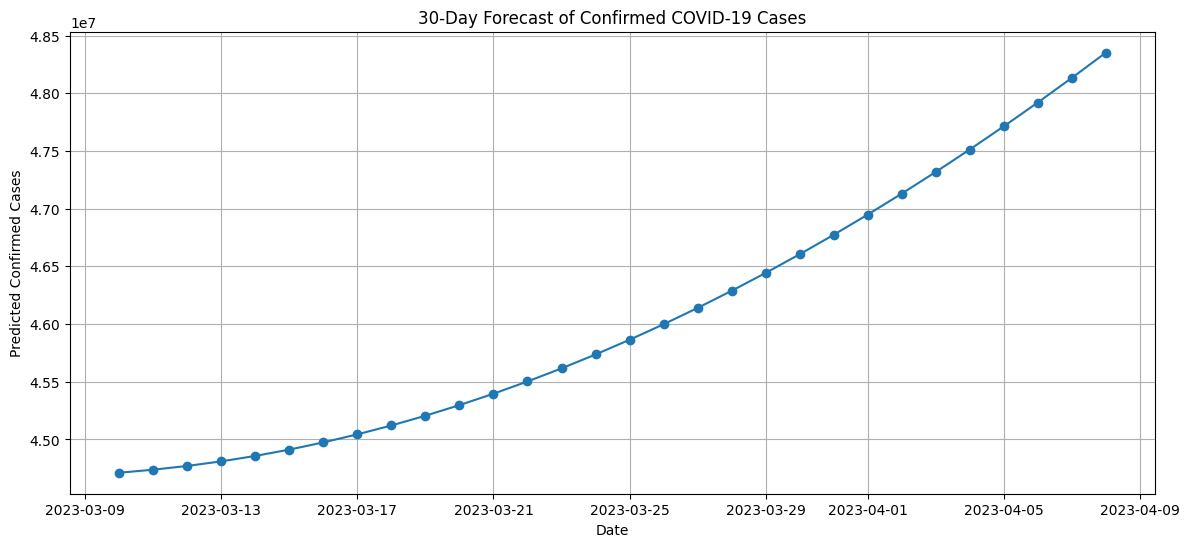

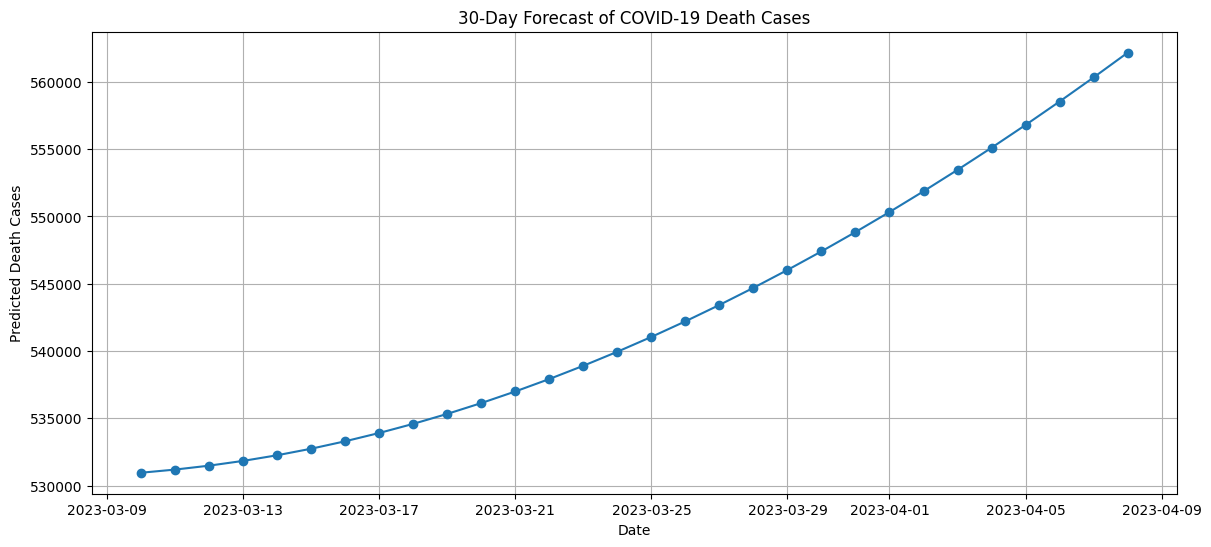

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(forecast_df["Date"], forecast_df["Predicted_Confirmed_Cases"], marker="o")
plt.title("30-Day Forecast of Confirmed COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Predicted Confirmed Cases")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(forecast_df["Date"], forecast_df["Predicted_Death_Cases"], marker="o")
plt.title("30-Day Forecast of COVID-19 Death Cases")
plt.xlabel("Date")
plt.ylabel("Predicted Death Cases")
plt.grid(True)
plt.show()

## 23. Model Comparison Report

The model comparison was done separately for confirmed cases and death cases.

### Confirmed Cases

The best model for confirmed cases is selected based on the lowest RMSE value.

### Death Cases

The best model for death cases is also selected based on the lowest RMSE value.

### Production Recommendation

For production use, the recommended model should have:

- Low MAE
- Low RMSE
- High R² score
- Stable prediction behavior

In [23]:
print("Confirmed Cases Model Comparison:")
display(case_results_df)

print()
print("Death Cases Model Comparison:")
display(death_results_df)

print()
print("Recommended Model for Confirmed Cases:", best_case_model_name)
print("Recommended Model for Death Cases:", best_death_model_name)

Confirmed Cases Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,12771.671115,13491.733092,0.994368
1,Random Forest Regressor,678083.216491,701508.872842,-14.227334
2,Gradient Boosting Regressor,696185.696731,719021.817834,-14.997115



Death Cases Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,134.623646,162.124888,0.987714
1,Random Forest Regressor,3454.461579,3751.358334,-5.577915
2,Gradient Boosting Regressor,3680.580152,3960.562436,-6.332041



Recommended Model for Confirmed Cases: Linear Regression
Recommended Model for Death Cases: Linear Regression


## 24. Government Health Department Suggestions

Based on the COVID-19 forecast, the government health department can consider the following actions:

### 1. Hospital Resource Planning

Hospitals should prepare enough beds, ICU facilities, oxygen supply, medicines, and emergency equipment based on the expected trend.

### 2. Testing and Monitoring

If the forecast shows an increase in cases, testing and monitoring should be increased in high-risk areas.

### 3. Public Awareness

The government should continue awareness campaigns related to hygiene, mask usage during outbreaks, and early symptom reporting.

### 4. Vaccination and Booster Planning

Booster vaccination campaigns should be strengthened for elderly people and high-risk groups if the trend shows a possible increase.

### 5. Data-Based Decision Making

Health departments should continue tracking daily cases and update the model regularly with new data.

### 6. Regional Preparedness

If state-wise or district-wise data is available, separate models can be created for high-risk regions.

## 25. Challenges Faced and Techniques Used

### Challenge 1: Cumulative Data

The Johns Hopkins dataset provides cumulative confirmed cases and deaths.

**Technique Used:**  
Daily cases and daily deaths were calculated using the difference between consecutive days.

### Challenge 2: Date Columns Were in Wide Format

The dataset had one column for each date, which is not ideal for time-series analysis.

**Technique Used:**  
The dataset was converted into a clean time-series format where each row represents one date.

### Challenge 3: Sudden COVID-19 Waves and Spikes

COVID-19 data can have sudden spikes because of new variants, reporting delays, changes in testing, and policy changes.

**Technique Used:**  
Previous day values and 7-day rolling averages were created as features to smooth short-term fluctuations.

### Challenge 4: Time-Series Data Cannot Be Split Randomly

Random splitting may leak future information into training data.

**Technique Used:**  
The data was split chronologically. Older records were used for training and recent records were used for testing.

### Challenge 5: Future Forecasting Has Uncertainty

COVID-19 spread depends on many external factors such as vaccination, new variants, lockdown rules, and public behavior.

**Technique Used:**  
The forecast period was limited to 30 days to keep the prediction practical and realistic.

## 26. Final Conclusion

This project analyzed the Johns Hopkins COVID-19 dataset and built forecasting models for India.

The analysis included cumulative confirmed cases, cumulative deaths, daily case trends, daily death trends, mortality rate, and correlation analysis.  
For prediction, multiple machine learning models were compared, including Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.

The best model was selected based on MAE, RMSE, and R² score.  
A 30-day forecast was created for confirmed cases and death cases.

The results can help government health departments prepare for hospital capacity, testing, vaccination planning, public awareness, and emergency healthcare requirements.

Overall, this project shows how healthcare data can support better planning and decision-making during a public health crisis.